# MERRA-2 Streaming Test

Notebook showing how we can stream NASA's MERRA-2 data directly from the relevant S3 AWS bucket, instead of having to download it all.

Jimmy Butler, 2024, following along with [this notebook](https://disc.gsfc.nasa.gov/information/howto?keywords=%22Earthdata%20Cloud%22&title=How%20to%20Directly%20Access%20MERRA-2%20Data%20from%20an%20S3%20Bucket%20with%20Python%20from%20a%20Cloud%20Environment).

In [1]:
from netrc import netrc
import xarray as xr
import boto3
from subprocess import Popen
from getpass import getpass

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from IPython.display import display, Markdown
import warnings
import os
import requests
import s3fs

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.path as mpath
#import cmocean

from matplotlib import animation
from IPython.display import Video

For some reason, you can only stream the data if you are in AWS us-west-2 region. This little code block checks that you are in the right region.

In [2]:
if (boto3.client('s3').meta.region_name == 'us-west-2'):
    display(Markdown('### us-west-2 Region Check: &#x2705;'))
else:
    display(Markdown('### us-west-2 Region Check: &#10060;'))
    raise ValueError('Your notebook is not running inside the AWS us-west-2 region, and will not be able to directly access NASA Earthdata S3 buckets')

### us-west-2 Region Check: &#x2705;

Login credentials stuff.

In [3]:
urs = 'urs.earthdata.nasa.gov'    # Earthdata URL endpoint for authentication
prompts = ['Enter NASA Earthdata Login Username: ',
           'Enter NASA Earthdata Login Password: ']

netrc_name = ".netrc"

# Determine if netrc file exists, and if so, if it includes NASA Earthdata Login Credentials
try:
    netrcDir = os.path.expanduser(f"~/{netrc_name}")
    # Check credentials against URS, and if username exists
    netrc(netrcDir).authenticators(urs)[0]

# Below, create a netrc file and prompt user for NASA Earthdata Login Username and Password
except FileNotFoundError:
    homeDir = os.path.expanduser("~")
    Popen('touch {0}{2} | echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)
    # Set restrictive permissions
    Popen('chmod 0600 {0}{1}'.format(homeDir + os.sep, netrc_name), shell=True)

In [5]:


# Below, create a netrc file and prompt user for NASA Earthdata Login Username and Password

from pathlib import Path

homeDir = Path.expanduser("~")
Popen(f'touch {homeDir/netrc_name} | echo machine {urs} >> {homeDir/netrc_name}', shell=True)
Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)
# Set restrictive permissions
Popen('chmod 0600 {0}{1}'.format(homeDir + os.sep, netrc_name), shell=True)

AttributeError: 'str' object has no attribute '_drv'

Then, you get an S3 token to access the data bucket, but apparently this only lasts for a couple hours and may need to be rerun periodically.

In [7]:
gesdisc_s3 = "https://data.gesdisc.earthdata.nasa.gov/s3credentials"

# Define a function for S3 access credentials

def begin_s3_direct_access(url: str=gesdisc_s3):
    response = requests.get(url).json()
    return s3fs.S3FileSystem(key=response['accessKeyId'],
                             secret=response['secretAccessKey'],
                             token=response['sessionToken'],
                             client_kwargs={'region_name':'us-west-2'})

fs = begin_s3_direct_access()

# Check that the file system is intact as an S3FileSystem object, which means that token is valid
# Common causes of rejected S3 access tokens include incorrect passwords stored in the netrc file, or a non-existent netrc file
type(fs)

s3fs.core.S3FileSystem

In [8]:
# Files are organized by s3://gesdisc-cumulus-prod-protected/MERRA2/M2T1NXSLV.5.12.4/year/mo/*.nc4

days = [15, 16, 17, 18]
datasets = []

for day in days:
    
    path = f's3://gesdisc-cumulus-prod-protected/MERRA2/M2I1NXASM.5.12.4/2022/03/MERRA2_400.inst1_2d_asm_Nx.202203{day}.nc4'
    dat = xr.open_dataset(fs.open(path), decode_cf=True,)
    antarctic_dat = dat.sel(lat = slice(-90.0, -50.0), lon = slice(-180, 179.4))
    datasets.append(antarctic_dat[['T2M', 'TQV', 'V10M']])

In [9]:
tot_dataset = xr.concat(datasets, dim='time')

### Plotting Moisture During the Antarctic Heat Wave AR

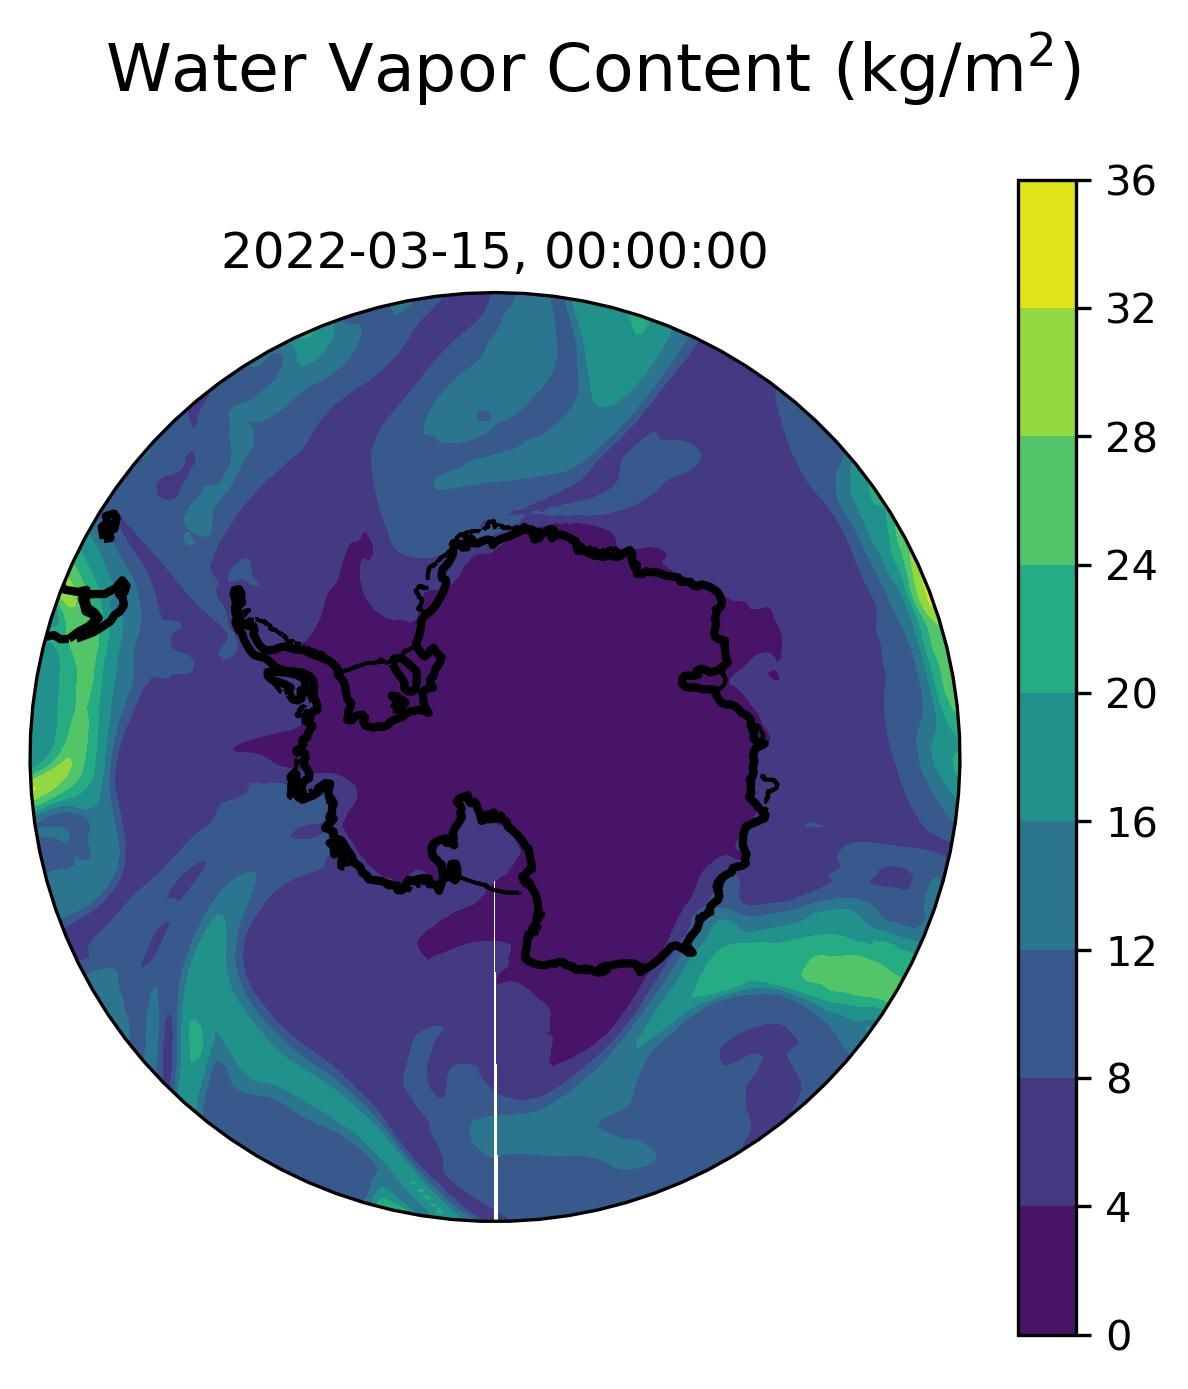

In [25]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)), dpi=300)
ax.set_extent([-180,179.4,-90,-50], ccrs.PlateCarree())
ax.coastlines(resolution='110m',linewidth=0.2,zorder=14)

minimum = tot_dataset.TQV.min().to_numpy()
maximum = tot_dataset.TQV.max().to_numpy()

CS = ax.contourf(tot_dataset.lon,tot_dataset.lat, tot_dataset.TQV[0,:,:],transform=ccrs.PlateCarree(), levels=10, vmin=minimum, vmax=maximum)
plt.title(str(tot_dataset.time.dt.date.to_numpy()[0]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[0]))

fig.colorbar(CS)
fig.suptitle('Water Vapor Content (kg/m$^2$)', fontsize=16)

def update_img(i):
    ax.clear()
    ax.set_extent([-180,180,-90,-50], ccrs.PlateCarree())
    ax.coastlines(resolution='110m',linewidth=2,zorder=14)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.contourf(tot_dataset.lon,tot_dataset.lat, tot_dataset.TQV[i,:,:],transform=ccrs.PlateCarree(), vmin=minimum, vmax=maximum, levels=10)
    ax.set_title(str(tot_dataset.time.dt.date.to_numpy()[i]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[i]))
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)


ani = animation.FuncAnimation(fig, update_img, frames=len(tot_dataset.time))

In [26]:
ani.save('iwv_2022heatwave.mp4')

In [34]:
Video('iwv_2022heatwave.mp4')

### 2M Temperature

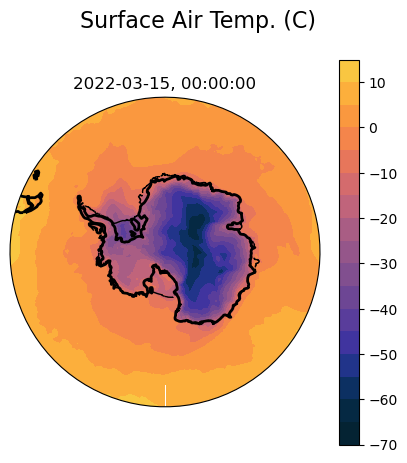

In [40]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
ax.set_extent([-180,179.4,-90,-50], ccrs.PlateCarree())
ax.coastlines(resolution='110m',linewidth=0.2,zorder=14)
cmap = cmocean.cm.thermal

minimum = tot_dataset.T2M.min().to_numpy() - 273.15
maximum = tot_dataset.T2M.max().to_numpy() - 273.15

CS = ax.contourf(tot_dataset.lon,tot_dataset.lat, tot_dataset.T2M[0,:,:]-273.15,transform=ccrs.PlateCarree(), levels=15, vmin=minimum, vmax=maximum, cmap=cmap)
plt.title(str(tot_dataset.time.dt.date.to_numpy()[0]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[0]))


fig.colorbar(CS)
fig.suptitle('Surface Air Temp. (C)', fontsize=16)

def update_img(i):
    ax.clear()
    ax.set_extent([-180,180,-90,-50], ccrs.PlateCarree())
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.coastlines(resolution='110m',linewidth=2,zorder=14)
    ax.contourf(tot_dataset.lon,tot_dataset.lat, tot_dataset.T2M[i,:,:]-273.15,transform=ccrs.PlateCarree(), vmin=minimum, vmax=maximum, levels=15, cmap=cmap)
    ax.set_title(str(tot_dataset.time.dt.date.to_numpy()[i]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[i]))
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

ani = animation.FuncAnimation(fig, update_img, frames=len(tot_dataset.time))

In [41]:
ani.save('t10m_2022heatwave.mp4')

In [42]:
Video('t10m_2022heatwave.mp4')

### Meridional winds?

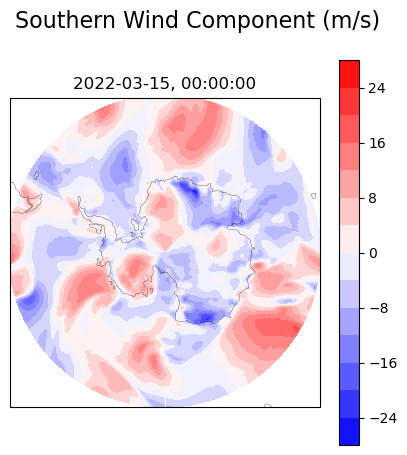

In [43]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
ax.set_extent([-180,179.4,-90,-50], ccrs.PlateCarree())
ax.coastlines(resolution='110m',linewidth=0.2,zorder=14)

s_wind = tot_dataset.V10M*(-1)

largest = round(max(abs(s_wind.min().to_numpy()), abs(s_wind.max().to_numpy())))

minimum = -largest
maximum = largest

#colormap = matplotlib.colors.ListedColormap(['bwr'])

CS = ax.contourf(tot_dataset.lon,tot_dataset.lat, s_wind[0,:,:],transform=ccrs.PlateCarree(), levels= np.linspace(minimum, maximum, 15), cmap='bwr')
plt.title(str(tot_dataset.time.dt.date.to_numpy()[0]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[0]))


fig.colorbar(CS)
fig.suptitle('Southern Wind Component (m/s)', fontsize=16)

def update_img(i):
    ax.clear()
    ax.set_extent([-180,180,-90,-50], ccrs.PlateCarree())
    ax.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    ax.contourf(tot_dataset.lon,tot_dataset.lat, s_wind[i,:,:],transform=ccrs.PlateCarree(), vmin=minimum, vmax=maximum, levels=15, cmap='bwr')
    ax.set_title(str(tot_dataset.time.dt.date.to_numpy()[i]) + ', ' + str(tot_dataset.time.dt.time.to_numpy()[i]))

ani = animation.FuncAnimation(fig, update_img, frames=len(tot_dataset.time))

In [44]:
ani.save('v10m_2022heatwave.mp4')

In [45]:
Video('v10m_2022heatwave.mp4')